In [1]:
!pip install yfinance

**Import library yang dibutuhkan**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

**install dan ambil data BBCA**

In [4]:
df = yf.download("BBCA.JK", start="2022-01-01", end="2024-01-01")

print(df.shape)
print(df.head())

/tmp/ipykernel_55/2912374900.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BBCA.JK", start="2022-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

(485, 5)
Price             Close         High          Low         Open     Volume
Ticker          BBCA.JK      BBCA.JK      BBCA.JK      BBCA.JK    BBCA.JK
Date                                                                     
2022-01-03  6297.416504  6361.895171  6275.923615  6297.416504   54287400
2022-01-04  6361.894531  6404.880305  6297.415870  6297.415870   70624000
2022-01-05  6404.881348  6469.360019  6340.402676  6404.881348   76164900
2022-01-06  6426.374023  6469.359803  6383.388244  6447.866913   63657100
2022-01-07  6576.824219  6619.809998  6447.866881  6490.852660  143433300


**mendefinisikan kolom bbca**

In [5]:
df.columns = df.columns.get_level_values(0)
print(df.columns)
print(df.head())

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Price             Close         High          Low         Open     Volume
Date                                                                     
2022-01-03  6297.416504  6361.895171  6275.923615  6297.416504   54287400
2022-01-04  6361.894531  6404.880305  6297.415870  6297.415870   70624000
2022-01-05  6404.881348  6469.360019  6340.402676  6404.881348   76164900
2022-01-06  6426.374023  6469.359803  6383.388244  6447.866913   63657100
2022-01-07  6576.824219  6619.809998  6447.866881  6490.852660  143433300


In [6]:
close = df['Close']
df['log_return'] = np.log(close/close.shift(1))

print(df['log_return'].describe())
print("\nskewness:", round(df['log_return'].skew(), 4))
print("kurtosis:", round(df['log_return'].kurt(), 4))

count    484.000000
mean       0.000606
std        0.012909
min       -0.066798
25%       -0.006585
50%        0.000000
75%        0.006999
max        0.042320
Name: log_return, dtype: float64

skewness: -0.1405
kurtosis: 2.0906


**log return**,
BBCA periode Jan 2022 – Jan 2024 bergerak relatif normal dan stabil, sedikit cenderung turun lebih dalam dari naik, tapi tidak ada kejadian ekstrem yang signifikan.

**visualisasi**

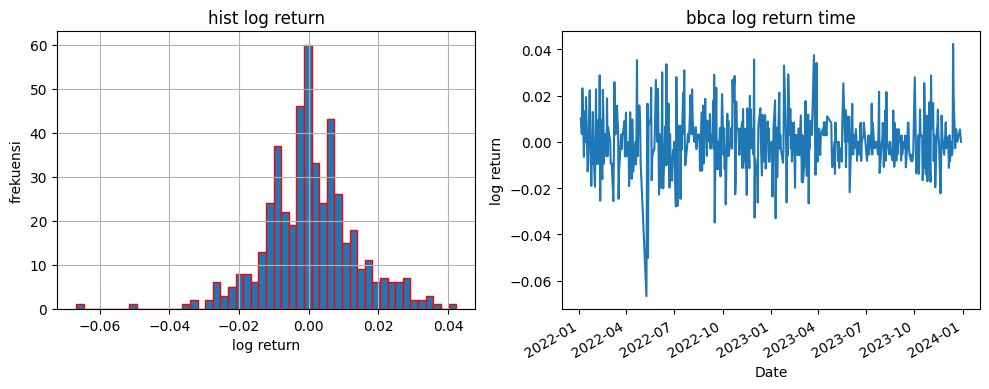

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))

#histogram return
plt.subplot(1, 2, 1)
df['log_return'].hist(bins = 50, edgecolor='red')
plt.title('hist log return')
plt.xlabel('log return')
plt.ylabel('frekuensi')

#time series log return
plt.subplot(1, 2, 2)
df['log_return'].plot()
plt.title('bbca log return time')
plt.xlabel('Date')
plt.ylabel('log return')

plt.tight_layout()
plt.show()

* Histogram — bentuknya seperti lonceng tapi tidak sempurna, ada ekor kiri yang sedikit lebih panjang. Itu konsisten dengan skewness -0.145 yang didapat tadi.
* Time series — mengkonfirmasi dua periode volatil itu. 2022 awal sampai pertengahan itu bertepatan dengan dampak perang Rusia-Ukraina dan kenaikan suku bunga The Fed agresif. Akhir 2023 ada tekanan global lagi dari kekhawatiran resesi AS. BBCA sebagai saham perbankan sensitif terhadap isu suku bunga — itu sebabnya volatilitasnya naik di periode itu.

**outlier**

In [8]:
df['zscore'] = (df['log_return'] - df['log_return'].mean())/df['log_return'].std()

#tampilan
outliers = df[df['zscore'].abs() > 3]
print("jumlah outliers", len(outliers))
print(outliers[['Close', 'log_return', 'zscore']].sort_values('zscore'))

jumlah outliers 3
Price             Close  log_return    zscore
Date                                         
2022-05-09  6633.973145   -0.066798 -5.221362
2022-05-12  6350.283691   -0.050262 -3.940429
2023-12-14  8127.619141    0.042320  3.231371


1. 2022-05-09 dan 2022-05-12, disini ada masalah energi. dimana uni eropa membuat proposal untuk tidak lagi mengimport minyak dari rusia karena manuver panas rusia ke ukraine yang menyebabkan hanrga minyak melambung dan the fed menaikan suku bunga 50 bps sebersar 1,00%.  bad news (perang, minyak, Fed hawkish) → investor kabur dari ekuitas
2. 2023-12-14, disini the fed menahan suku bunga di angka 5.5 %. hal ini menurunkan yield us treasury dan mendorong reli tajam ke ekuitas global serta adanya red sea crisis. pada log return di tahun 2022 minus sedangkan pada 2023 positif.  good news (Fed pivot signal) → investor masuk balik ke ekuitas

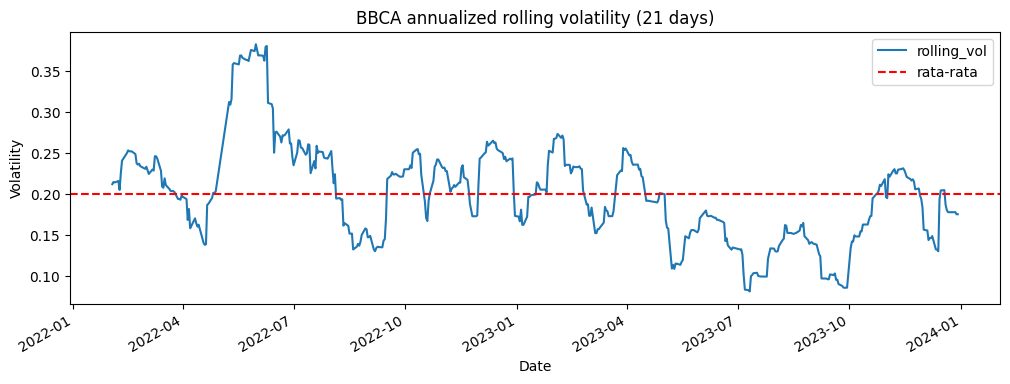

rata rata volatilitas tahunan: 19.95%


In [10]:
df['rolling_vol'] = df['log_return'].rolling(window=21).std() * np.sqrt(252)

plt.figure(figsize=(12, 4))
df['rolling_vol'].plot()
plt.title('BBCA annualized rolling volatility (21 days)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.axhline(df['rolling_vol'].mean(), color='red', linestyle='--', label='rata-rata')
plt.legend()
plt.show()

print(f"rata rata volatilitas tahunan: {df['rolling_vol'].mean():.2%}")

## Rolling Volatility Analysis
Rata-rata volatilitas tahunan BBCA periode 2022-2024 adalah 19.95%.
Terdapat dua periode volatilitas ekstrem:
- Mei 2022: dipicu kenaikan Fed Funds Rate dan krisis energi Eropa
- Desember 2023: sinyal pivot Fed mendorong reli tajam

Secara umum volatilitas 2023 lebih rendah dari 2022, 
mengindikasikan stabilisasi pasar pasca ketidakpastian global.

In [18]:
from statsmodels.tsa.stattools import adfuller
# adf test close
result_price = adfuller(df['Close'])
print("===ADF Test Harga Close===")
print(f"ADF statistic:{result_price[0]:.4f}")
print(f"p-value: {result_price[1]:.4f}")
print("kesimpulan:", {'stasioner' if result_price[1] < 0.05 else "tidak stasioner"})

print()
# adf test log return
result_ret = adfuller(df['log_return'].dropna())
print("===ADF Test log return===")
print(f"ADF statistic:{result_ret[0]:.4f}")
print(f"p-value: {result_ret[1]:.4f}")
print("kesimpulan:", {'stasioner' if result_ret[1] < 0.05 else "tidak stasioner"})

===ADF Test Harga Close===
ADF statistic:-1.5312
p-value: 0.5180
kesimpulan: {'tidak stasioner'}

===ADF Test log return===
ADF statistic:-25.2592
p-value: 0.0000
kesimpulan: {'stasioner'}


Harga Close p-value 0.518 jauh di atas 0.05 — gagal tolak hipotesis nol, artinya ada unit root, data tidak stasioner. Harga saham "mengembara" tanpa mean yang tetap, tidak bisa dimodelkan langsung.
Log Returns p-value 0.000 dan ADF statistic -25.259 yang sangat negatif — tolak hipotesis nol dengan sangat kuat. Data stasioner, mean dan variansinya stabil.